<a href="https://colab.research.google.com/github/cdhakami-p/CSCI-B455/blob/main/hw2/q1/hw2_q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework 2 Question 1**

In [ ]:
# LLMs were used in certain labeled sections of the code, as well as to bug fix and clean up code overall
# Used textbook for code references
# Import initial libraries and dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Load datasets (only first 480 rows)
features = pd.read_csv("feature_presence540.txt", sep=r"\s+", header=None)
labels = pd.read_excel("aggregateRockData.xlsx")

# Used AI to help bugfix first 3 attribute columns not appearing
features = features.iloc[:480].apply(pd.to_numeric, errors='coerce')
labels = labels.iloc[:480]

token_numbers = features.iloc[:,2]
token_numbers = pd.to_numeric(token_numbers)

X = features.iloc[:, 3:14]
y = labels.iloc[:,1]

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

# Splitting the data

train_split = token_numbers.between(7,16)
val_split = token_numbers.between(4,6)
test_split = token_numbers.between(1,3)

X_train = X[train_split]
y_train = y[train_split]

X_val = X[val_split]
y_val = y[val_split]

X_test = X[test_split]
y_test = y[test_split]

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Feature matrix shape: (480, 11)
Label vector shape: (480,)
Train size: (300, 11)
Validation size: (90, 11)
Test size: (90, 11)


# **PART 1:**




In [ ]:
# Statistical Summary

X_train.columns = [f"Feature_{i}" for i in range(1, 12)]

display(X_train.describe().T)


,count,mean,std,min,25%,50%,75%,max
Feature_1,300.0,0.087000,0.193622,0.0,0.0,0.00,0.05,1.00
Feature_2,300.0,0.081667,0.196407,0.0,0.0,0.00,0.05,1.00
Feature_3,300.0,0.061367,0.180137,0.0,0.0,0.00,0.00,1.00
Feature_4,300.0,0.037333,0.154821,0.0,0.0,0.00,0.00,1.00
Feature_5,300.0,0.171900,0.224919,0.0,0.0,0.10,0.25,0.95
Feature_6,300.0,0.052167,0.099851,0.0,0.0,0.05,0.05,0.90
Feature_7,300.0,0.144167,0.264905,0.0,0.0,0.00,0.10,1.00
Feature_8,300.0,0.135667,0.167196,0.0,0.0,0.05,0.20,0.95
Feature_9,300.0,0.039000,0.156292,0.0,0.0,0.00,0.00,1.00
Feature_10,300.0,0.025167,0.112771,0.0,0.0,0.00,0.00,1.00


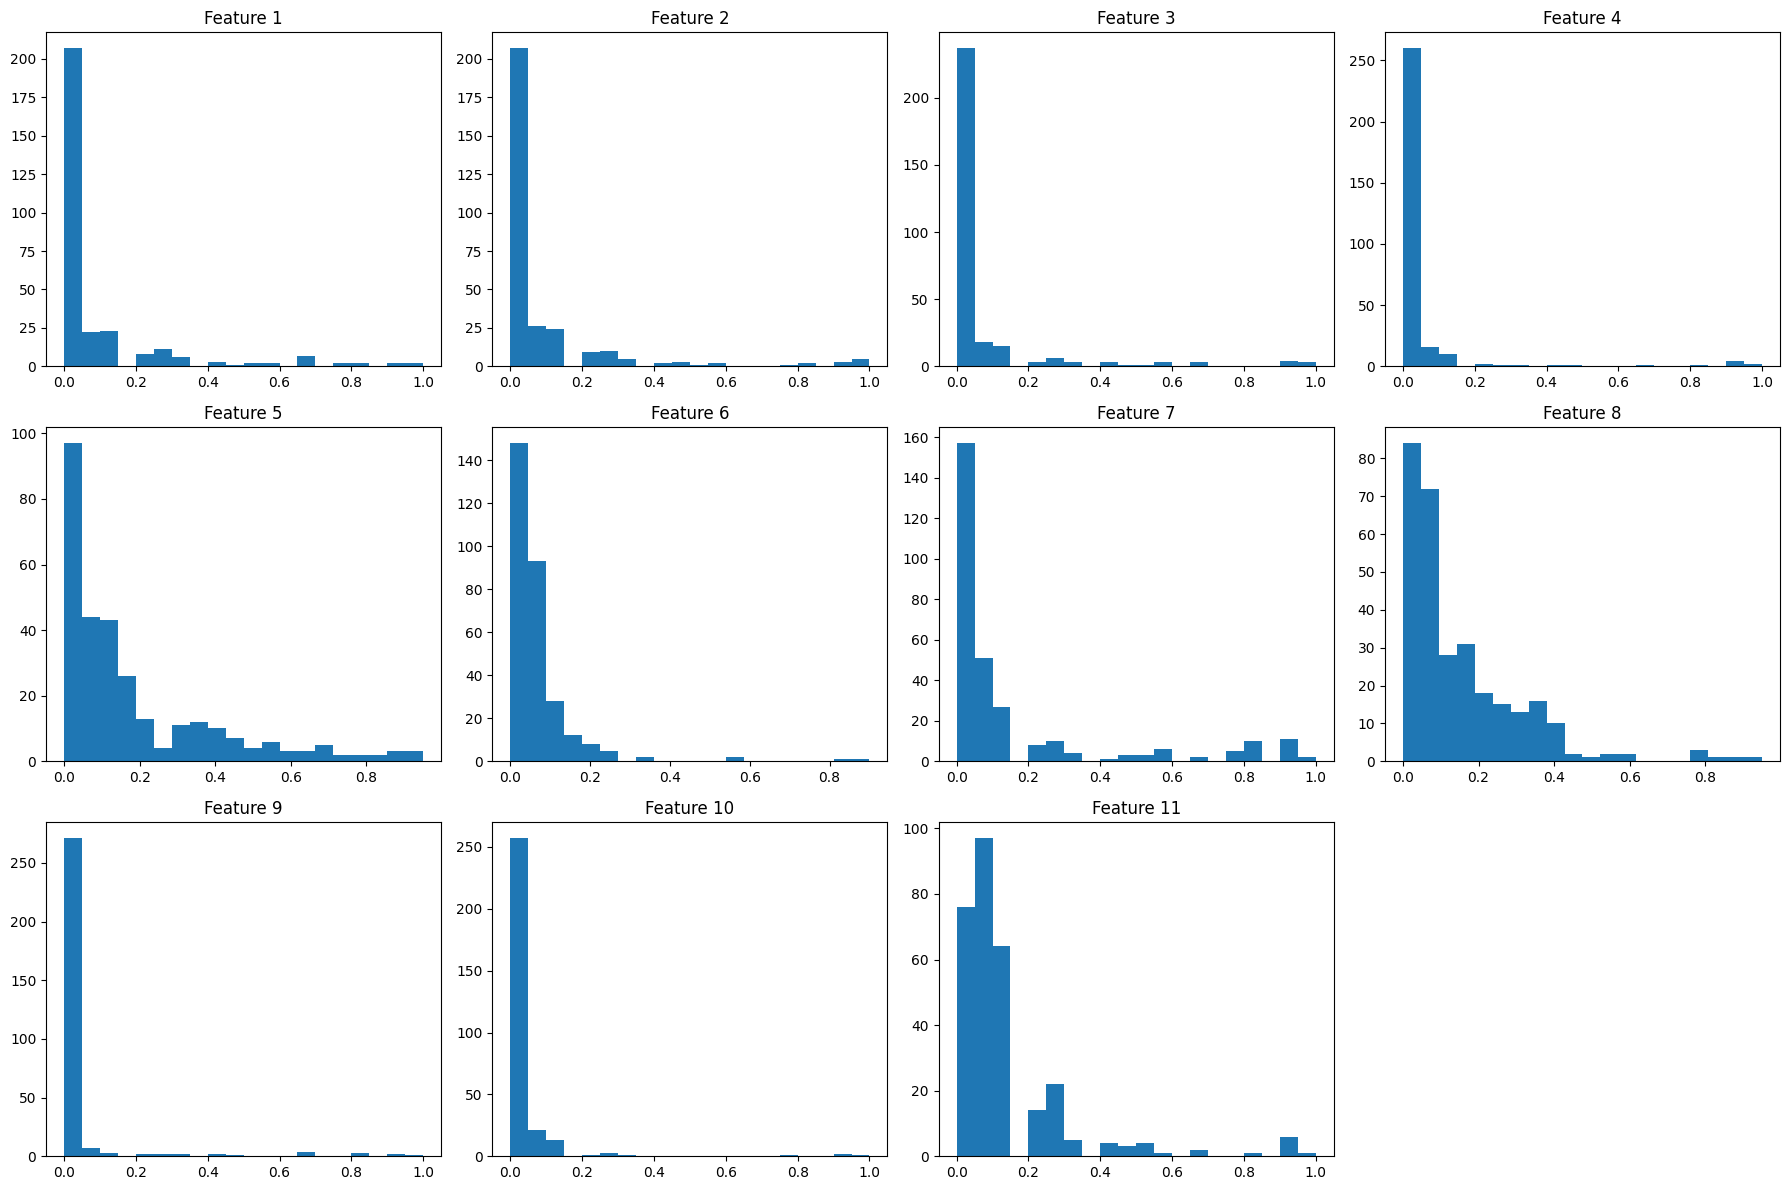

In [ ]:
# Boxplots

plt.figure(figsize=(18,12))

for i in range(11):
    plt.subplot(3,4,i+1)
    plt.hist(X_train.iloc[:, i], bins=20)
    plt.title(f"Feature {i+1}")

plt.tight_layout()
plt.show()

In [ ]:
# Check for skew

display(X_train.skew())

,0
Feature_1,2.798990
Feature_2,3.304229
Feature_3,3.697402
Feature_4,5.197598
Feature_5,1.663202
Feature_6,4.987633
Feature_7,2.021660
Feature_8,2.056341
Feature_9,4.545315
Feature_10,7.014868


**Part 1 Summary:**

Feature_1 – Angular fragments
 - Mean = 0.087, STD = 0.194

Feature_2 – Rounded fragments
 - Mean = 0.082, STD = 0.196

Feature_3 – Straight stripes
 - Mean = 0.061, STD = 0.180

Feature_4 – Curved stripes
 - Mean = 0.037, STD = 0.155

Feature_5 – Physical layers
 - Mean = 0.172, STD = 0.225

Feature_6 – Veins
 - Mean = 0.052, STD = 0.100

Feature_7 – Oily/Shimmery texture
 - Mean = 0.144, STD = 0.265
 - Highest STD of all features, most spread out distribution

Feature_8 – Splotchy
 - Mean = 0.136, STD = 0.167

Feature_9 – Single translucent crystal
 - Mean = 0.039, STD = 0.156

Feature_10 – Multiple cubic crystals
 - Mean = 0.025, STD = 0.113

Feature_11 – Sandy texture
 - Mean = 0.123, STD = 0.180

All features are already on a [0,1] scale so min-max normalization is not needed. However, all features show strong right skew and a cluster of values at 0. Standardization would be helpful before applying SVM and logistic regression due to the differences in variance. Features 9 and 10 are almost always 0, so they may not be as helpful for classification.

# **PART 2:**



In [ ]:
# Create correlation matrix

corr_matrix = X_train.corr()

display(corr_matrix)

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11
Feature_1,1.000000,0.295807,-0.132009,-0.101461,-0.237043,-0.139093,-0.149011,0.084106,-0.109735,-0.031300,-0.153250
Feature_2,0.295807,1.000000,-0.123218,-0.074205,-0.246359,-0.136103,-0.177066,0.019470,-0.104104,-0.031194,-0.122793
Feature_3,-0.132009,-0.123218,1.000000,0.185302,-0.020470,0.064542,-0.092242,-0.141042,-0.016689,-0.061050,0.116901
Feature_4,-0.101461,-0.074205,0.185302,1.000000,-0.105916,0.037478,-0.075812,-0.100387,-0.057264,-0.050642,-0.068717
Feature_5,-0.237043,-0.246359,-0.020470,-0.105916,1.000000,0.084477,0.189240,-0.277821,-0.113334,-0.131573,-0.062544
Feature_6,-0.139093,-0.136103,0.064542,0.037478,0.084477,1.000000,-0.103518,0.064971,-0.047223,-0.082083,-0.084458
Feature_7,-0.149011,-0.177066,-0.092242,-0.075812,0.189240,-0.103518,1.000000,-0.245230,-0.013268,-0.062801,-0.310116
Feature_8,0.084106,0.019470,-0.141042,-0.100387,-0.277821,0.064971,-0.245230,1.000000,-0.087326,-0.068164,-0.148005
Feature_9,-0.109735,-0.104104,-0.016689,-0.057264,-0.113334,-0.047223,-0.013268,-0.087326,1.000000,0.099726,-0.151764
Feature_10,-0.031300,-0.031194,-0.061050,-0.050642,-0.131573,-0.082083,-0.062801,-0.068164,0.099726,1.000000,-0.114840


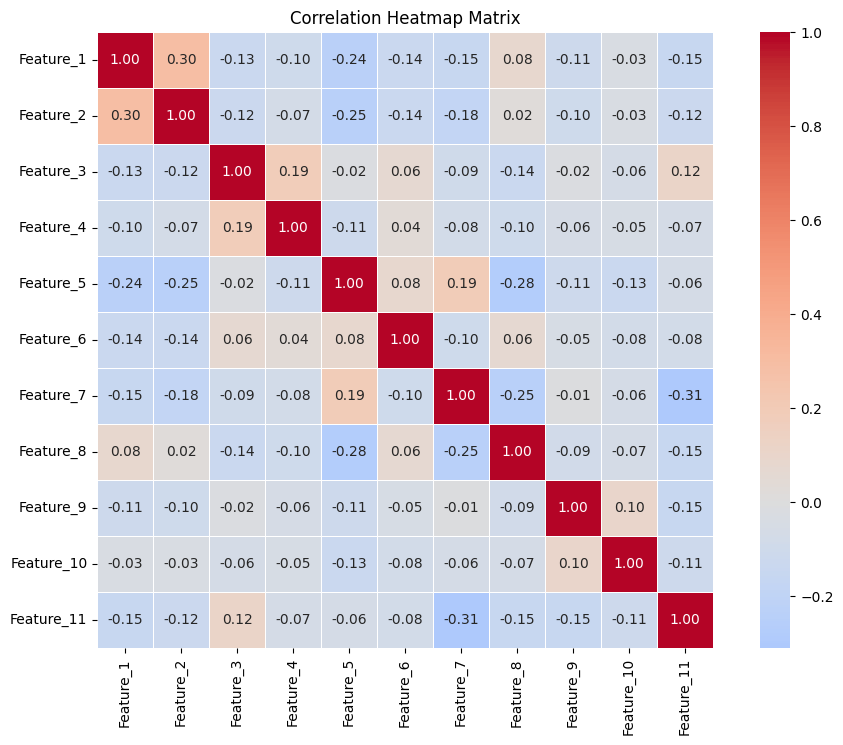

In [ ]:
# Heatmap matrix

plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)

plt.title("Correlation Heatmap Matrix")
plt.show()

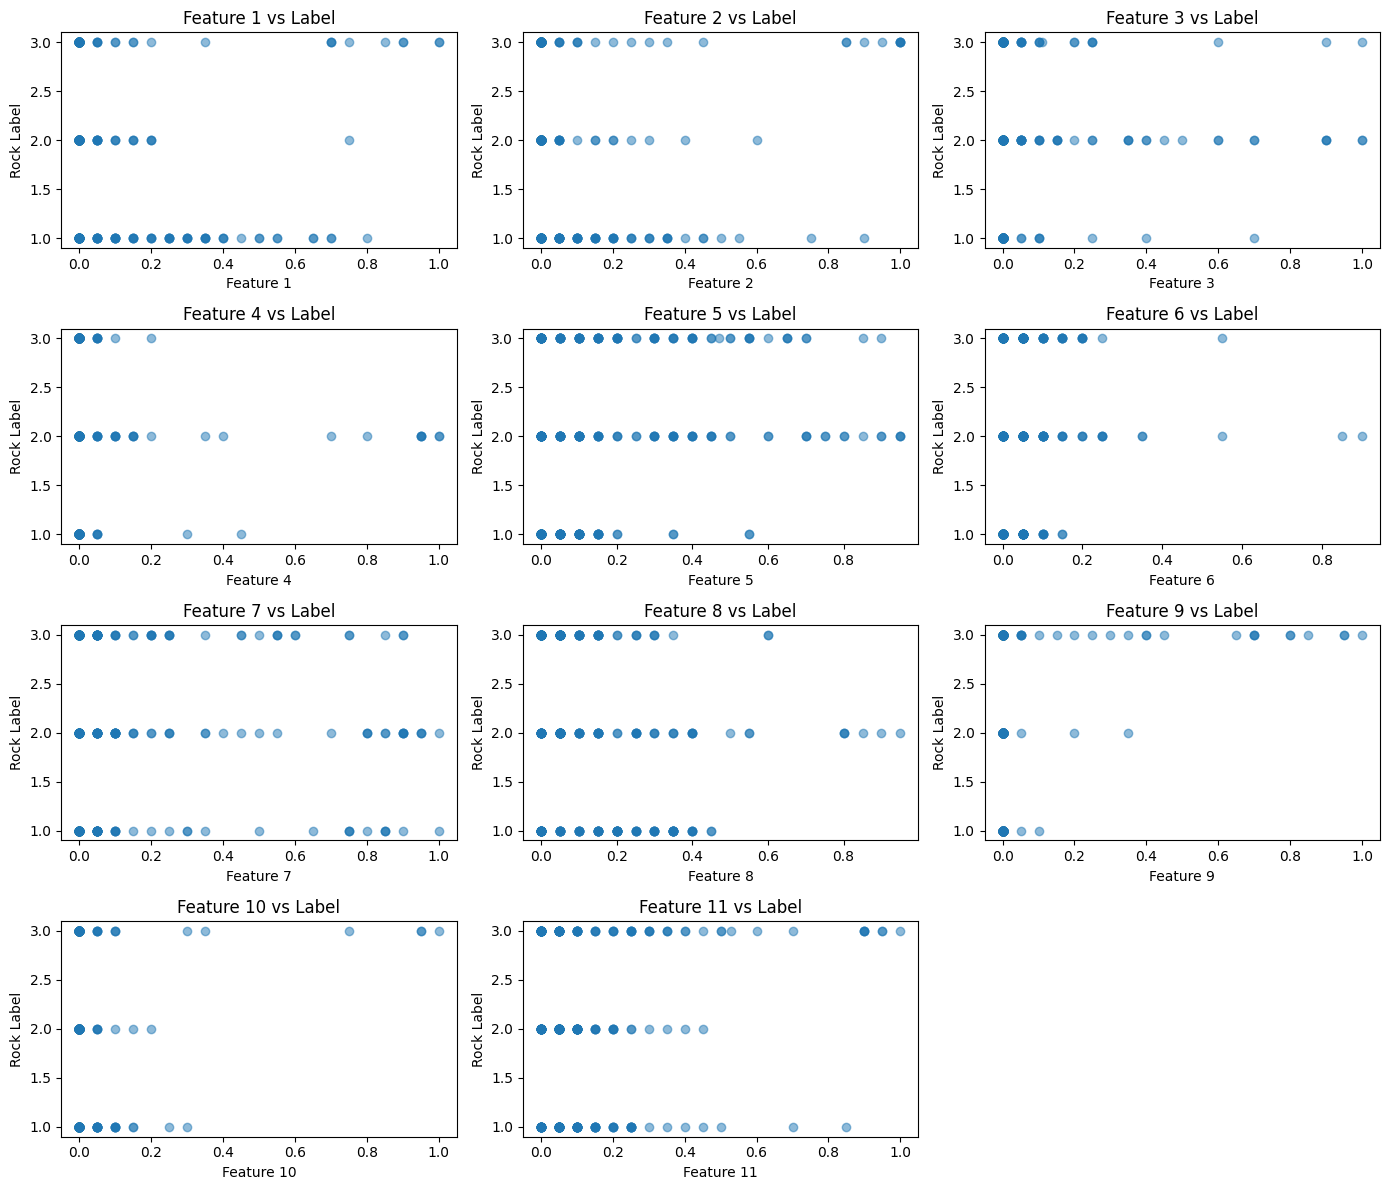

In [ ]:
# Scatter Plots

num_features = X_train.shape[1]

cols = 3
rows = math.ceil(num_features / cols)

plt.figure(figsize=(14, rows*3))

for i in range(num_features):

    plt.subplot(rows, cols, i+1)

    plt.scatter(
        X_train.iloc[:, i],
        y_train,
        alpha=0.5
    )

    plt.title(f"Feature {i+1} vs Label")
    plt.xlabel(f"Feature {i+1}")
    plt.ylabel("Rock Label")

plt.tight_layout()
plt.show()

**Part 2 Summary:**

The correlation heatmap shows that most  correlations are small, generally between about −0.3 and 0.3. This means the attributes are not strongly related to each other and there is little risk of multicollinearity. Overall, the features appear to be mostly independent.

Scatter plots of each feature versus the rock label show that the three classes have a lot of overlap. Since the labels are discrete, the points form horizontal lines, and most single features do not clearly separates the classes. A couple features such as Feature 9 do show a slightly more of a trend with label 3 having higher values, but most do not separate classes in this way. This suggests that classification will likely require using multiple features together rather than relying on one attribute.

# **PART 3:**

In [ ]:
print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (300, 11)
Validation size: (90, 11)
Test size: (90, 11)


**Part 3 Summary:**

The data is split using token numbers, where each of the 30 rock subtypes has 16
tokens representing different samples of that subtype.

 - Train: tokens 7-16 - 300 samples (30 subtypes × 10 tokens)
 - Validation: tokens 4-6 - 90 samples (30 subtypes × 3 tokens)
 - Test: tokens 1-3 - 90 samples (30 subtypes × 3 tokens)

# **PART 4:**


In [ ]:
# Import from sklearn and scaling

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Softmax Regression (Part A)

import warnings
warnings.filterwarnings('ignore')

C_values = [0.01, 0.1, 1.0, 10.0]
solvers = ['lbfgs', 'saga', 'newton-cg']
max_iters = [100, 500, 1000]

results = []

for C in C_values:
    for solver in solvers:
        for max_iter in max_iters:
            model = LogisticRegression(C=C, solver=solver, max_iter=max_iter)
            model.fit(X_train_scaled, y_train)

            preds = model.predict(X_val_scaled)

            results.append({
                'C': C, 'solver': solver, 'max_iter': max_iter,
                'Val Accuracy':  round(accuracy_score(y_val, preds), 4),
                'Val Precision': round(precision_score(y_val, preds, average='macro'), 4),
                'Val Recall':    round(recall_score(y_val, preds, average='macro'), 4),
                'Val F1':        round(f1_score(y_val, preds, average='macro'), 4),
            })

results_df = pd.DataFrame(results)
display(results_df.sort_values('Val Accuracy', ascending=False))

,C,solver,max_iter,Val Accuracy,Val Precision,Val Recall,Val F1
16,0.10,newton-cg,500,0.6333,0.6354,0.6333,0.6333
9,0.10,lbfgs,100,0.6333,0.6354,0.6333,0.6333
11,0.10,lbfgs,1000,0.6333,0.6354,0.6333,0.6333
10,0.10,lbfgs,500,0.6333,0.6354,0.6333,0.6333
26,1.00,newton-cg,1000,0.6333,0.6347,0.6333,0.6332
25,1.00,newton-cg,500,0.6333,0.6347,0.6333,0.6332
19,1.00,lbfgs,500,0.6333,0.6347,0.6333,0.6332
24,1.00,newton-cg,100,0.6333,0.6347,0.6333,0.6332
15,0.10,newton-cg,100,0.6333,0.6354,0.6333,0.6333
14,0.10,saga,1000,0.6333,0.6354,0.6333,0.6333


In [ ]:
# Softmax Regression (Part A) - Best model from val acc. above

best_model = LogisticRegression(C=0.1, solver='lbfgs', max_iter=100)
best_model.fit(X_train_scaled, y_train)

train_pred = best_model.predict(X_train_scaled)
val_pred = best_model.predict(X_val_scaled)
test_pred = best_model.predict(X_test_scaled)

print("Train Accuracy: ", round(accuracy_score(y_train, train_pred), 4))
print("Train Precision: ", round(precision_score(y_train, train_pred, average='macro'), 4))
print("Train Recall: ", round(recall_score(y_train, train_pred, average='macro'), 4))
print("Train F1: ", round(f1_score(y_train, train_pred, average='macro'), 4))

print("\nVal Accuracy: ", round(accuracy_score(y_val, val_pred), 4))
print("Val Precision: ", round(precision_score(y_val, val_pred, average='macro'), 4))
print("Val Recall: ", round(recall_score(y_val, val_pred, average='macro'), 4))
print("Val F1: ", round(f1_score(y_val, val_pred, average='macro'), 4))

print("\nTest Accuracy: ", round(accuracy_score(y_test, test_pred), 4))
print("Test Precision: ", round(precision_score(y_test, test_pred, average='macro'), 4))
print("Test Recall: ", round(recall_score(y_test, test_pred, average='macro'), 4))
print("Test F1: ", round(f1_score(y_test, test_pred, average='macro'), 4))

Train Accuracy:  0.7167
Train Precision:  0.7216
Train Recall:  0.7167
Train F1:  0.7146

Val Accuracy:  0.6333
Val Precision:  0.6354
Val Recall:  0.6333
Val F1:  0.6333

Test Accuracy:  0.6333
Test Precision:  0.6561
Test Recall:  0.6333
Test F1:  0.6234


In [ ]:
# SVM (Part B)

from sklearn.svm import SVC

C_values = [0.1, 1.0, 10.0]
kernels = ['linear', 'rbf', 'poly']
degrees = [2, 3, 4]
gammas = ['scale', 'auto']

results_svm = []

for C in C_values:
    for kernel in kernels:
        for gamma in gammas:
            for degree in degrees:
                if kernel != 'poly' and degree != degrees[0]:
                    continue

                model = SVC(C=C, kernel=kernel, degree=degree, gamma=gamma)
                model.fit(X_train_scaled, y_train)

                preds = model.predict(X_val_scaled)

                results_svm.append({
                    'C': C, 'kernel': kernel, 'degree': degree, 'gamma': gamma,
                    "Val Accuracy":  round(accuracy_score(y_val, preds), 4),
                    "Val Precision": round(precision_score(y_val, preds, average='macro'), 4),
                    "Val Recall":    round(recall_score(y_val, preds, average='macro'), 4),
                    'Val F1':        round(f1_score(y_val, preds, average='macro'), 4),
                })

results_svm_df = pd.DataFrame(results_svm)
display(results_svm_df.sort_values('Val Accuracy', ascending=False))

,C,kernel,degree,gamma,Val Accuracy,Val Precision,Val Recall,Val F1
10,1.0,linear,2,scale,0.6778,0.6896,0.6778,0.6756
11,1.0,linear,2,auto,0.6778,0.6896,0.6778,0.6756
21,10.0,linear,2,auto,0.6778,0.6887,0.6778,0.6763
20,10.0,linear,2,scale,0.6778,0.6887,0.6778,0.6763
0,0.1,linear,2,scale,0.6556,0.6613,0.6556,0.6523
1,0.1,linear,2,auto,0.6556,0.6613,0.6556,0.6523
22,10.0,rbf,2,scale,0.6556,0.6603,0.6556,0.6507
23,10.0,rbf,2,auto,0.6556,0.6603,0.6556,0.6507
25,10.0,poly,3,scale,0.6444,0.6740,0.6444,0.6367
28,10.0,poly,3,auto,0.6444,0.6740,0.6444,0.6367


In [ ]:
# SVM (Part B) - Best model from val acc. above

best_svm = SVC(C=1.0, kernel="linear", degree=2, gamma='scale')
best_svm.fit(X_train_scaled, y_train)

train_pred = best_svm.predict(X_train_scaled)
val_pred = best_svm.predict(X_val_scaled)
test_pred = best_svm.predict(X_test_scaled)

print("Train Accuracy: ", round(accuracy_score(y_train, train_pred), 4))
print("Train Precision: ", round(precision_score(y_train, train_pred, average='macro'), 4))
print("Train Recall: ", round(recall_score(y_train, train_pred, average='macro'), 4))
print("Train F1: ", round(f1_score(y_train, train_pred, average='macro'), 4))

print("\nVal Accuracy: ", round(accuracy_score(y_val, val_pred), 4))
print("Val Precision: ", round(precision_score(y_val, val_pred, average='macro'), 4))
print("Val Recall: ", round(recall_score(y_val, val_pred, average='macro'), 4))
print("Val F1: ", round(f1_score(y_val, val_pred, average='macro'), 4))

print("\nTest Accuracy: ", round(accuracy_score(y_test, test_pred), 4))
print("Test Precision: ", round(precision_score(y_test, test_pred, average='macro'), 4))
print("Test Recall: ", round(recall_score(y_test, test_pred, average='macro'), 4))
print("Test F1: ", round(f1_score(y_test, test_pred, average='macro'), 4))

Train Accuracy:  0.7233
Train Precision:  0.735
Train Recall:  0.7233
Train F1:  0.7201

Val Accuracy:  0.6778
Val Precision:  0.6896
Val Recall:  0.6778
Val F1:  0.6756

Test Accuracy:  0.6889
Test Precision:  0.7246
Test Recall:  0.6889
Test F1:  0.6766


In [ ]:
# Random Forest (Part C)

from sklearn.ensemble import RandomForestClassifier

n_estimators_values = [50, 100, 200]
max_depth_values = [None, 5, 10]
min_samples_split_values = [2, 5, 10]
min_samples_leaf_values = [1, 2, 4]

results_rf = []

for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        for min_samples_split in min_samples_split_values:
            for min_samples_leaf in min_samples_leaf_values:
                model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth,
                                               min_samples_split=min_samples_split,
                                               min_samples_leaf=min_samples_leaf, random_state=42)
                model.fit(X_train, y_train)

                preds = model.predict(X_val)

                results_rf.append({
                    'n_estimators': n_estimators, 'max_depth': max_depth,
                    'min_samples_split': min_samples_split, 'min_samples_leaf': min_samples_leaf,
                    'Val Accuracy':  round(accuracy_score(y_val, preds), 4),
                    'Val Precision': round(precision_score(y_val, preds, average='macro'), 4),
                    'Val Recall':    round(recall_score(y_val, preds, average='macro'), 4),
                    'Val F1':        round(f1_score(y_val, preds, average='macro'), 4),
                })

results_rf_df = pd.DataFrame(results_rf)
display(results_rf_df.sort_values('Val Accuracy', ascending=False))

,n_estimators,max_depth,min_samples_split,min_samples_leaf,Val Accuracy,Val Precision,Val Recall,Val F1
21,50,10.0,5,1,0.6444,0.6478,0.6444,0.6445
33,100,NaN,10,1,0.6444,0.6512,0.6444,0.6437
51,100,10.0,10,1,0.6333,0.6373,0.6333,0.6317
48,100,10.0,5,1,0.6222,0.6327,0.6222,0.6236
79,200,10.0,10,2,0.6222,0.6267,0.6222,0.6214
...,...,...,...,...,...,...,...,...
8,50,NaN,10,4,0.5556,0.5669,0.5556,0.5543
12,50,5.0,5,1,0.5556,0.5581,0.5556,0.5532
19,50,10.0,2,2,0.5556,0.5571,0.5556,0.5554
14,50,5.0,5,4,0.5444,0.5461,0.5444,0.5420


In [ ]:
# Random Forest (Part C) - Best model from val acc. above

best_rf = RandomForestClassifier(n_estimators=50, max_depth=10,
                                  min_samples_split=5, min_samples_leaf=1,
                                  random_state=42)
best_rf.fit(X_train, y_train)

train_pred = best_rf.predict(X_train)
val_pred = best_rf.predict(X_val)
test_pred = best_rf.predict(X_test)

print("Train Accuracy: ", round(accuracy_score(y_train, train_pred), 4))
print("Train Precision: ", round(precision_score(y_train, train_pred, average='macro'), 4))
print("Train Recall: ", round(recall_score(y_train, train_pred, average='macro'), 4))
print("Train F1: ", round(f1_score(y_train, train_pred, average='macro'), 4))

print("\nVal Accuracy: ", round(accuracy_score(y_val, val_pred), 4))
print("Val Precision: ", round(precision_score(y_val, val_pred, average='macro'), 4))
print("Val Recall: ", round(recall_score(y_val, val_pred, average='macro'), 4))
print("Val F1: ", round(f1_score(y_val, val_pred, average='macro'), 4))

print("\nTest Accuracy: ", round(accuracy_score(y_test, test_pred), 4))
print("Test Precision: ", round(precision_score(y_test, test_pred, average='macro'), 4))
print("Test Recall: ", round(recall_score(y_test, test_pred, average='macro'), 4))
print("Test F1: ", round(f1_score(y_test, test_pred, average='macro'), 4))

Train Accuracy:  0.94
Train Precision:  0.94
Train Recall:  0.94
Train F1:  0.94

Val Accuracy:  0.6444
Val Precision:  0.6478
Val Recall:  0.6444
Val F1:  0.6445

Test Accuracy:  0.6889
Test Precision:  0.6899
Test Recall:  0.6889
Test F1:  0.6883


**Part 4 Summary:**

Softmax Regression (Best: C=0.1, solver=lbfgs, max_iter=100)
 - Train: 0.7167, Val: 0.6333, Test: 0.6333
 - C=0.1 performed best. Both very high regularization (C=0.01) and very low
   regularization (C=10.0) lowered accuracy. Solver and max_iter had no impact on performance once convergence was reached, meaning all solvers converge quickly on
   this dataset.

SVM (Best: C=1.0, kernel=linear, gamma=scale)
 - Train: 0.7233, Val: 0.6778, Test: 0.6889
 - Linear kernel outperformed rbf and poly, suggesting the classes are
   linearly separable. Higher C (10.0) with linear kernel keeps same performance, but adds complexity. Poly kernel
   performed worst overall across all degrees and gamma values.

Random Forest (Best: n_estimators=50, max_depth=10, min_samples_split=5, min_samples_leaf=1)
 - Train: 0.94, Val: 0.6444, Test: 0.6889
 - The large gap between train (0.94) and val (0.6444) shows overfitting. Increasing n_estimators past 50 didn't seem to improve validation accuracy.

Overall, SVM with a linear kernel performed best on validation and test sets.
Softmax regression was the weakest of the three. Random Forest overfit the
training data significantly but still achieved reasonable test performance
comparable to SVM.

# **PART 5:**


In [ ]:
# Ensemble
# Also ran code using soft voting, but changed code back to hard as it was the better model

from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(estimators=[('softmax', best_model), ('svm', best_svm), ('rf', best_rf)], voting='hard')

ensemble.fit(X_train_scaled, y_train)

# Used for part 6
ensemble_soft = VotingClassifier(estimators=[('softmax', best_model), ('svm', SVC(C=1.0, kernel='linear', gamma='scale', probability=True)), ('rf', best_rf)], voting='soft')
ensemble_soft.fit(X_train_scaled, y_train)

train_pred = ensemble.predict(X_train_scaled)
val_pred = ensemble.predict(X_val_scaled)
test_pred = ensemble.predict(X_test_scaled)

print("Train Accuracy: ", round(accuracy_score(y_train, train_pred), 4))
print("Train Precision: ", round(precision_score(y_train, train_pred, average='macro'), 4))
print("Train Recall: ", round(recall_score(y_train, train_pred, average='macro'), 4))
print("Train F1: ", round(f1_score(y_train, train_pred, average='macro'), 4))

print("\nVal Accuracy: ", round(accuracy_score(y_val, val_pred), 4))
print("Val Precision: ", round(precision_score(y_val, val_pred, average='macro'), 4))
print("Val Recall: ", round(recall_score(y_val, val_pred, average='macro'), 4))
print("Val F1: ", round(f1_score(y_val, val_pred, average='macro'), 4))

print("\nTest Accuracy: ", round(accuracy_score(y_test, test_pred), 4))
print("Test Precision: ", round(precision_score(y_test, test_pred, average='macro'), 4))
print("Test Recall: ", round(recall_score(y_test, test_pred, average='macro'), 4))
print("Test F1: ", round(f1_score(y_test, test_pred, average='macro'), 4))

Train Accuracy:  0.75
Train Precision:  0.7596
Train Recall:  0.75
Train F1:  0.7486

Val Accuracy:  0.6556
Val Precision:  0.6589
Val Recall:  0.6556
Val F1:  0.6553

Test Accuracy:  0.6667
Test Precision:  0.7063
Test Recall:  0.6667
Test F1:  0.6564


**Part 5 Summary:**

Used two ensemble approaches, soft and hard, both combined softmax regression, SVM, and random forest models.

Hard voting:
 - Val: 0.6556, Test: 0.6667

Soft voting:
 - Val: 0.6444, Test: 0.7000

The hard voting ensemble outperformed Softmax (0.6333) and Random Forest
(0.6444) on validation but performed worse than SVM (0.6778). The soft voting
ensemble showed similar results. Neither ensemble was able to perform better than the best individual classifier, SVM.

This suggests that since SVM is already the strongest model, adding the
weaker Softmax and Random Forest predictions into the vote reduces the overall accuracy rather than improving it.

# **PART 6:**



In [ ]:
# Human Comparison

trial_data = pd.read_csv('trialData.csv')

#trial_data.head()
#trial_data.shape

filtered_rocks = trial_data[(trial_data['block'] == 4) & (trial_data['rocknumber'] <= 480)]

human_acc = filtered_rocks.groupby('rocknumber')['cat_correct'].mean()

print("Average human accuracy:", round(human_acc.mean(), 4))
print("Number of rocks:", len(human_acc))


Average human accuracy: 0.5984
Number of rocks: 480


In [ ]:
# Human Comparison - model probabilities

X_all_scaled = scaler.transform(X)

softmax_prob = best_model.predict_proba(X_all_scaled)
svm_prob = SVC(C=1.0, kernel='linear', gamma='scale', probability=True).fit(X_train_scaled, y_train).predict_proba(X_all_scaled)
rf_prob = best_rf.predict_proba(X_all_scaled)
ensemble_prob = ensemble_soft.predict_proba(X_all_scaled)

y_all = y.values
class_id = y_all - 1

softmax_correct_prob = softmax_prob[np.arange(len(y_all)), class_id]
svm_correct_prob = svm_prob[np.arange(len(y_all)), class_id]
rf_correct_prob = rf_prob[np.arange(len(y_all)), class_id]
ensemble_correct_prob = ensemble_prob[np.arange(len(y_all)), class_id]

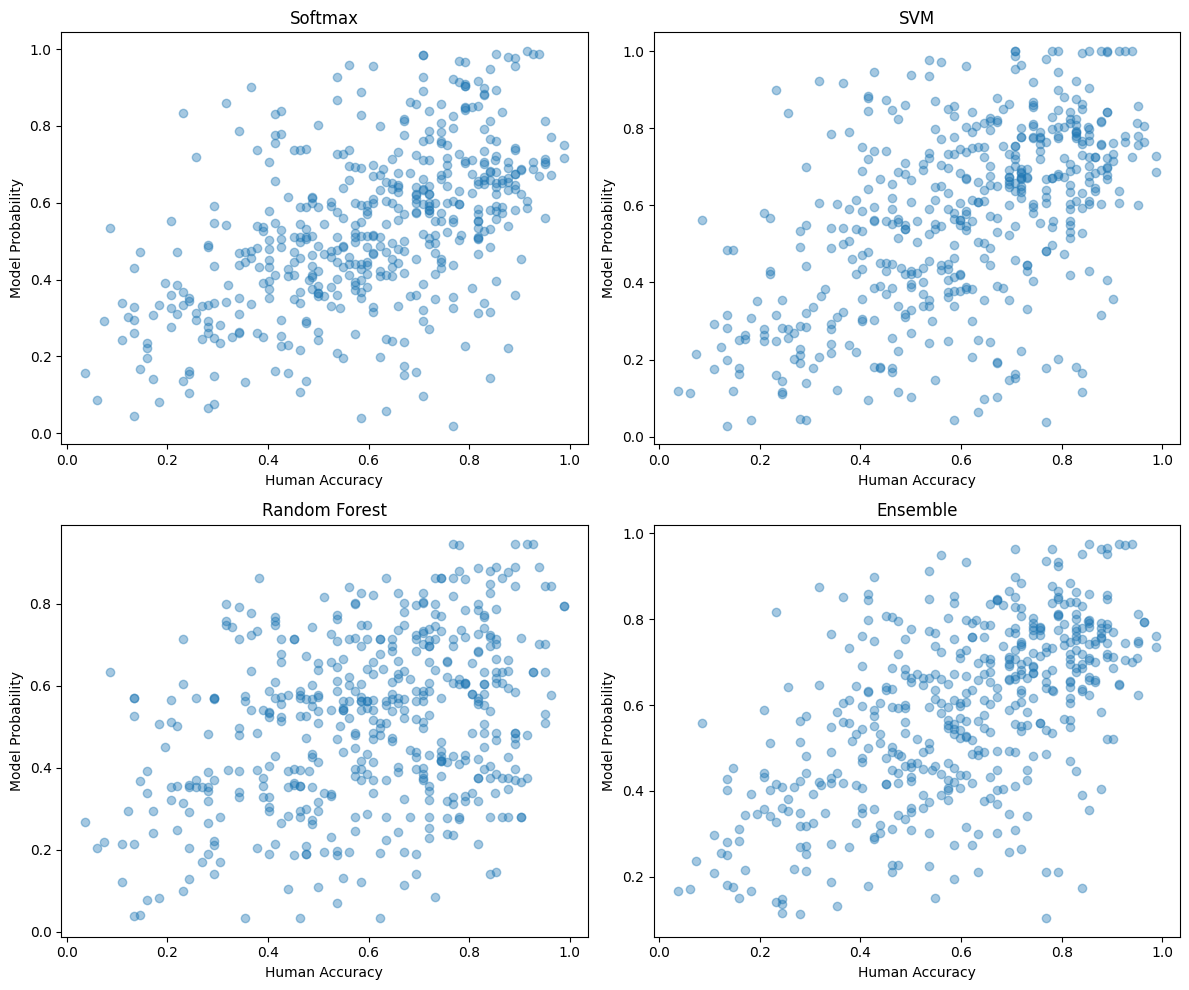

In [ ]:
# Human Comparison - human probabilities & plots

rock_numbers = np.arange(1,481)

human_acc_id = human_acc.reindex(rock_numbers).values

plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
plt.scatter(human_acc_id, softmax_correct_prob, alpha=0.4)
plt.title("Softmax")
plt.xlabel("Human Accuracy")
plt.ylabel("Model Probability")

plt.subplot(2,2,2)
plt.scatter(human_acc_id, svm_correct_prob, alpha=0.4)
plt.title("SVM")
plt.xlabel("Human Accuracy")
plt.ylabel("Model Probability")

plt.subplot(2,2,3)
plt.scatter(human_acc_id, rf_correct_prob, alpha=0.4)
plt.title("Random Forest")
plt.xlabel("Human Accuracy")
plt.ylabel("Model Probability")

plt.subplot(2,2,4)
plt.scatter(human_acc_id, ensemble_correct_prob, alpha=0.4)
plt.title("Ensemble")
plt.xlabel("Human Accuracy")
plt.ylabel("Model Probability")

plt.tight_layout()
plt.show()

In [ ]:
# Human Comparison - human probabilities & plots

from scipy.stats import pearsonr

valid = ~np.isnan(human_acc_id)

r_soft, p_soft = pearsonr(human_acc_id[valid], softmax_correct_prob[valid])
r_svm, p_svm = pearsonr(human_acc_id[valid], svm_correct_prob[valid])
r_rf, p_rf = pearsonr(human_acc_id[valid], rf_correct_prob[valid])
r_ens, p_ens = pearsonr(human_acc_id[valid], ensemble_correct_prob[valid])

print("Softmax r:", round(r_soft,4), ", p =", f'{p_soft:.2e}')
print("SVM r:", round(r_svm,4), ", p =", f'{p_svm:.2e}')
print("RF r:", round(r_rf,4), ", p =", f'{p_rf:.2e}')
print("Ensemble r:", round(r_ens,4), ", p =", f'{p_ens:.2e}')

Softmax r: 0.5314 , p = 2.43e-36
SVM r: 0.5335 , p = 1.15e-36
RF r: 0.3461 , p = 5.93e-15
Ensemble r: 0.5844 , p = 2.66e-45


**Part 6 Summary:**

The relationship between human accuracy and model confidence was looked at using scatter plots and correlation. All models showed positive correlations, meaning that models tend to be more confident on rocks that humans also find easier to classify.

The ensemble model showed the strongest relationship with human performance (r ≈ 0.58), followed by Softmax and SVM. Random Forest showed a weaker but still positive relationship. The very small p-values indicate that these correlations are statistically significant.

This indicates that the ensemble model behaves most similarly to human judgments of rocks.